# 유저는 활동을 줄이기 전에 어떤 모습을 보이는가?

## 투표받는 횟수나 교류 상대 수가 줄어드는가? 

In [ ]:
!pip install pymysql

In [2]:
import pandas as pd
import numpy as np
import pymysql

In [3]:
from google.cloud import bigquery

PROJECT_ID = "sns-analysis-prj"
DATA_SET = "sns_analysis"

client = bigquery.Client(project=PROJECT_ID)

In [3]:
# accounts_user, accounts_userquestionrecord 테이블 불러오기
sql = f"""
    SELECT * 
    FROM `{PROJECT_ID}.{DATA_SET}.accounts_user`
"""
accounts_user = client.query(sql).to_dataframe()
display(accounts_user.head())

sql = f"""
    SELECT * 
    FROM `{PROJECT_ID}.{DATA_SET}.accounts_userquestionrecord`
"""
accounts_userquestionrecord = client.query(sql).to_dataframe()
display(accounts_userquestionrecord.head())

/Users/youju/anaconda3/envs/pythonProject/lib/python3.11/site-packages/google/cloud/bigquery/table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,id,is_superuser,is_staff,gender,point,friend_id_list,is_push_on,created_at,block_user_id_list,hide_user_id_list,ban_status,report_count,alarm_count,pending_chat,pending_votes,group_id
0,855284,0,0,F,5509,"[857088, 856981, 852248, 854554, 852124, 84739...",1,2023-04-29 16:13:15.312334+00:00,[],[],N,0,2,0,0,3319
1,862801,0,0,F,1515,"[858112, 853505, 852612, 853381, 853636, 85095...",1,2023-05-01 02:17:10.929300+00:00,[],[],N,0,1,0,0,3116
2,875116,0,0,F,1215,"[902016, 870790, 895369, 874250, 899721, 90459...",1,2023-05-03 09:02:41.931364+00:00,[],[],N,0,0,0,0,30
3,884169,0,0,F,271,"[911360, 898056, 945675, 987668, 942105, 99740...",1,2023-05-05 06:32:11.861364+00:00,"[1084651, 1173543]","[905750, 1090502]",N,0,0,1,0,12176
4,890678,0,0,F,4102,"[889601, 886786, 871937, 875908, 887813, 88730...",1,2023-05-05 23:43:22.667518+00:00,[],[],N,0,2,0,0,9533


/Users/youju/anaconda3/envs/pythonProject/lib/python3.11/site-packages/google/cloud/bigquery/table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,id,status,created_at,chosen_user_id,question_id,user_id,question_piece_id,has_read,answer_status,answer_updated_at,report_count,opened_times
0,945319,I,2023-04-29 13:22:05+00:00,849995,132,851717,1213085,1,P,2023-05-06 10:31:30+00:00,0,3
1,978922,I,2023-04-29 14:49:06+00:00,849922,180,849450,1235436,1,N,2023-04-29 14:49:06+00:00,0,3
2,1095692,I,2023-04-30 03:29:48+00:00,850031,132,850229,1395859,1,N,2023-04-30 03:29:48+00:00,0,3
3,1167181,I,2023-04-30 07:43:10+00:00,856172,116,857422,1509130,1,N,2023-04-30 07:43:10+00:00,0,3
4,1171173,I,2023-04-30 07:58:36+00:00,855039,132,855117,1511169,1,N,2023-04-30 07:58:36+00:00,0,3


In [4]:
print(accounts_user.info())

<class 'pandas.DataFrame'>
RangeIndex: 677080 entries, 0 to 677079
Data columns (total 16 columns):
 #   Column              Non-Null Count   Dtype              
---  ------              --------------   -----              
 0   id                  677080 non-null  Int64              
 1   is_superuser        677080 non-null  Int64              
 2   is_staff            677080 non-null  Int64              
 3   gender              677080 non-null  str                
 4   point               677080 non-null  Int64              
 5   friend_id_list      677080 non-null  str                
 6   is_push_on          677080 non-null  Int64              
 7   created_at          677080 non-null  datetime64[us, UTC]
 8   block_user_id_list  677080 non-null  str                
 9   hide_user_id_list   677080 non-null  str                
 10  ban_status          677080 non-null  str                
 11  report_count        677080 non-null  Int64              
 12  alarm_count         677080 

In [5]:
print(accounts_userquestionrecord.info())

<class 'pandas.DataFrame'>
RangeIndex: 1217558 entries, 0 to 1217557
Data columns (total 12 columns):
 #   Column             Non-Null Count    Dtype              
---  ------             --------------    -----              
 0   id                 1217558 non-null  Int64              
 1   status             1217558 non-null  str                
 2   created_at         1217558 non-null  datetime64[us, UTC]
 3   chosen_user_id     1217558 non-null  Int64              
 4   question_id        1217558 non-null  Int64              
 5   user_id            1217558 non-null  Int64              
 6   question_piece_id  1217558 non-null  Int64              
 7   has_read           1217558 non-null  Int64              
 8   answer_status      1217558 non-null  str                
 9   answer_updated_at  1217558 non-null  datetime64[us, UTC]
 10  report_count       1217558 non-null  Int64              
 11  opened_times       1217558 non-null  Int64              
dtypes: Int64(8), datetime64[u

In [6]:
# 날짜 형식으로 변환 (타임존 인식 날짜 계산 오류 방지를 위해 tz_localize(None) 처리)
accounts_user['created_at'] = pd.to_datetime(
    accounts_user['created_at']
).dt.tz_localize(None)
accounts_userquestionrecord['created_at'] = pd.to_datetime(
    accounts_userquestionrecord['created_at']
).dt.tz_localize(None)

In [7]:
# 컬럼명 충돌 방지를 위해 유저 테이블의 created_at 이름을 user_created_at으로 변경
accounts_user = accounts_user.rename(columns={'created_at': 'user_created_at'})

In [8]:
# 투표받은 유저(chosen_user_id) 기준으로 조인
df_merged = pd.merge(
    accounts_userquestionrecord,
    accounts_user,
    left_on='chosen_user_id',
    right_on='id',
    how='inner',
)

In [9]:
# 가입 후 경과 일수 및 주차 계산
df_merged['days_since_signup'] = (
    df_merged['created_at'] - df_merged['user_created_at']
).dt.days
df_merged['weeks_since_signup'] = df_merged['days_since_signup'] // 7

In [10]:
# 정제 및 집계
df_filtered = df_merged[
    (df_merged['days_since_signup'] >= 0)
    & (df_merged['weeks_since_signup'] <= 12)
]

user_weekly = (
    df_filtered.groupby(['chosen_user_id', 'weeks_since_signup'])
    .agg(
        votes_received=('id_x', 'count'),  # 투표받은 횟수
        interaction_partners=('user_id', 'nunique'),  # 고유 교류 상대 수
    )
    .reset_index()
)

weekly_trend = (
    user_weekly.groupby('weeks_since_signup')
    .agg(
        avg_votes_received=('votes_received', 'mean'),
        avg_interaction_partners=('interaction_partners', 'mean'),
    )
    .reset_index()
)

print(weekly_trend.head(10))

   weeks_since_signup  avg_votes_received  avg_interaction_partners
0                   0           67.417791                 12.442678
1                   1           20.332658                  6.821705
2                   2            9.254992                  4.077456
3                   3            5.387029                  2.827149
4                   4            4.057697                  2.161411
5                   5             2.89842                  1.686983
6                   6             2.22757                  1.376708
7                   7            1.920235                  1.283795
8                   8            1.575458                  1.165021
9                   9             1.56973                  1.176216


- 가입 직후인 0주차에 투표받은 횟수(약 67회)와 교류 상대 수(약 12.4명)가 가장 높음 
- 시간이 지날수록 빠르게 감소하면서 3~4주차가 지나면 급격히 안정화?되는 패턴

In [11]:
# 감소율 계산해서 확인
# 0주차 값을 기준(100%)으로 한 주차별 잔존 비율 계산
weekly_trend['vote_retention_rate'] = (
    weekly_trend['avg_votes_received']
    / weekly_trend.loc[0, 'avg_votes_received']
) * 100
weekly_trend['partner_retention_rate'] = (
    weekly_trend['avg_interaction_partners']
    / weekly_trend.loc[0, 'avg_interaction_partners']
) * 100

print(
    weekly_trend[
        [
            'weeks_since_signup',
            'vote_retention_rate',
            'partner_retention_rate',
        ]
    ]
)

    weeks_since_signup  vote_retention_rate  partner_retention_rate
0                    0                100.0              100.000000
1                    1            30.159188               54.825051
2                    2            13.727819               32.769921
3                    3             7.990515               22.721389
4                    4             6.018733               17.370946
5                    5             4.299191               13.558035
6                    6             3.304128               11.064405
7                    7             2.848262               10.317675
8                    8             2.336859                9.363106
9                    9             2.328361                9.453079
10                  10             2.224932                9.210866
11                  11             2.201008                9.088271
12                  12             1.978865                8.670853


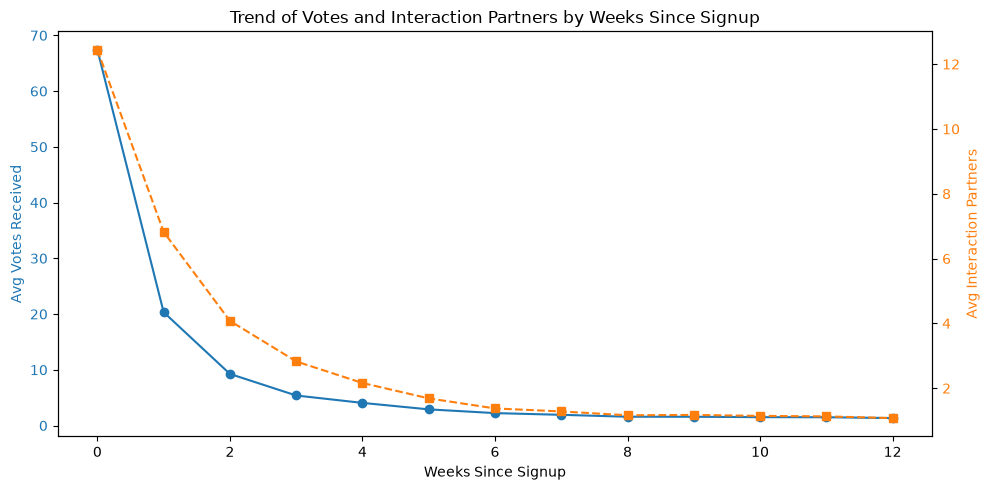

In [12]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(10, 5))

# 왼쪽 축: 평균 투표받은 횟수
color = 'tab:blue'
ax1.set_xlabel('Weeks Since Signup')
ax1.set_ylabel('Avg Votes Received', color=color)
(line1,) = ax1.plot(
    weekly_trend['weeks_since_signup'],
    weekly_trend['avg_votes_received'],
    color=color,
    marker='o',
    label='Votes Received',
)
ax1.tick_params(axis='y', labelcolor=color)

# 오른쪽 축: 평균 고유 교류 상대 수
ax2 = ax1.twinx()
color = 'tab:orange'
ax2.set_ylabel('Avg Interaction Partners', color=color)
(line2,) = ax2.plot(
    weekly_trend['weeks_since_signup'],
    weekly_trend['avg_interaction_partners'],
    color=color,
    marker='s',
    linestyle='--',
    label='Interaction Partners',
)
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Trend of Votes and Interaction Partners by Weeks Since Signup')
fig.tight_layout()
plt.show()

- **초반 급감 (1~2주차)**

- - 0주차 대비 1주차에 투표받는 횟수가 30.2%로 떨어지고, 2주차에는 13.7%까지 급감

- - 교류 상대 수는 1주차에 54.8%, 2주차에 32.8%로, 투표 수 감소 폭에 비해서는 상대적으로 높게 유지
- - - 즉, 관계의 폭(사람 수)보다는 투표의 빈도(횟수)가 더 가파르게 줄어듭니다

- **중장기 정체기 (3주차 이후)**

- - 3주차부터는 하락세가 둔화
- - 4주차 이후로는 투표 수 5% 미만, 교류 상대 수는 10% 내외로 수렴

- - 서비스 특성상 가입 직후 친구 초대나 초기 버프로 활성도가 폭발적으로 높다가, 3~4주가 지나면 핵심 코어 유저나 잔존 유저만 남는 전형적인 SNS/커뮤니티 코호트 패턴을 보인다

세그먼트 분석을 진행하볼까 했지만, 세그먼트 분석은 전체적인 행동 데이터로 하는 게 더 좋을 것 같아 일단 진행하지 않았음

### 툭 튀던 기간 데이터 제거하고, 확인해보기

In [13]:
sql = f"""
    SELECT * 
    FROM `{PROJECT_ID}.{DATA_SET}.accounts_attendance`
"""
accounts_attendance = client.query(sql).to_dataframe()
display(accounts_attendance.head())

/Users/youju/anaconda3/envs/pythonProject/lib/python3.11/site-packages/google/cloud/bigquery/table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,id,attendance_date_list,user_id
0,7923,"[""2023-05-27"", ""2023-05-28"", ""2023-05-29"", ""20...",1355335
1,38921,"[""2023-05-27"", ""2023-05-28"", ""2023-05-29"", ""20...",892265
2,777,"[""2023-05-27"", ""2023-05-28"", ""2023-05-29"", ""20...",913054
3,6557,"[""2023-05-27"", ""2023-05-28"", ""2023-05-29"", ""20...",947077
4,2534,"[""2023-05-27"", ""2023-05-28"", ""2023-05-29"", ""20...",1233366


In [14]:
# 1. 컬럼명과 상위 5개 행 데이터 확인
print("Columns:", accounts_attendance.columns)
print(accounts_attendance.head())

# 2. attendance_date_list 컬럼의 실제 데이터 타입 및 샘플 확인
print(
    "Sample attendance_date_list:",
    accounts_attendance['attendance_date_list'].head(5),
)

Columns: Index(['id', 'attendance_date_list', 'user_id'], dtype='str')
      id                               attendance_date_list  user_id
0   7923  ["2023-05-27", "2023-05-28", "2023-05-29", "20...  1355335
1  38921  ["2023-05-27", "2023-05-28", "2023-05-29", "20...   892265
2    777  ["2023-05-27", "2023-05-28", "2023-05-29", "20...   913054
3   6557  ["2023-05-27", "2023-05-28", "2023-05-29", "20...   947077
4   2534  ["2023-05-27", "2023-05-28", "2023-05-29", "20...  1233366
Sample attendance_date_list: 0    ["2023-05-27", "2023-05-28", "2023-05-29", "20...
1    ["2023-05-27", "2023-05-28", "2023-05-29", "20...
2    ["2023-05-27", "2023-05-28", "2023-05-29", "20...
3    ["2023-05-27", "2023-05-28", "2023-05-29", "20...
4    ["2023-05-27", "2023-05-28", "2023-05-29", "20...
Name: attendance_date_list, dtype: str


In [15]:
import re
import pandas as pd

daily_attendance_list = []

for idx, row in accounts_attendance.iterrows():
  user_id = row['user_id']
  date_list_str = row['attendance_date_list']

  if pd.isna(date_list_str):
    continue

  # 정규식을 이용해 문자열 안에서 'YYYY-MM-DD' 형식의 날짜들을 모두 찾아냄
  dates = re.findall(r'\d{4}-\d{2}-\d{2}', str(date_list_str))

  for d in dates:
    daily_attendance_list.append(
        {'date': pd.to_datetime(d).date(), 'user_id': user_id}
    )

print(
    f'추출된 총 데이터 개수: {len(daily_attendance_list)}개 (0보다 커야 정상)'
)

# 데이터가 잘 들어왔다면 데이터프레임 생성 및 집계 진행
if len(daily_attendance_list) > 0:
  df_attendance_daily = pd.DataFrame(daily_attendance_list)
  daily_dau = (
      df_attendance_daily.groupby('date')['user_id']
      .nunique()
      .reset_index(name='dau')
  )
  print(daily_dau.tail(10))

추출된 총 데이터 개수: 2222327개 (0보다 커야 정상)
           date  dau
323  2024-04-30   81
324  2024-05-01   91
325  2024-05-02   69
326  2024-05-03   67
327  2024-05-04   85
328  2024-05-05  107
329  2024-05-06  110
330  2024-05-07   60
331  2024-05-08   68
332  2024-05-09   46


--- 최근 DAU 데이터 요약 ---
           date  dau
318  2024-04-25   83
319  2024-04-26   74
320  2024-04-27  102
321  2024-04-28  121
322  2024-04-29   78
323  2024-04-30   81
324  2024-05-01   91
325  2024-05-02   69
326  2024-05-03   67
327  2024-05-04   85
328  2024-05-05  107
329  2024-05-06  110
330  2024-05-07   60
331  2024-05-08   68
332  2024-05-09   46

--- DAU 기초 통계 ---
count       333.000000
mean       6673.654655
std       21297.226156
min           1.000000
25%          87.000000
50%         329.000000
75%        3249.000000
max      172836.000000
Name: dau, dtype: float64


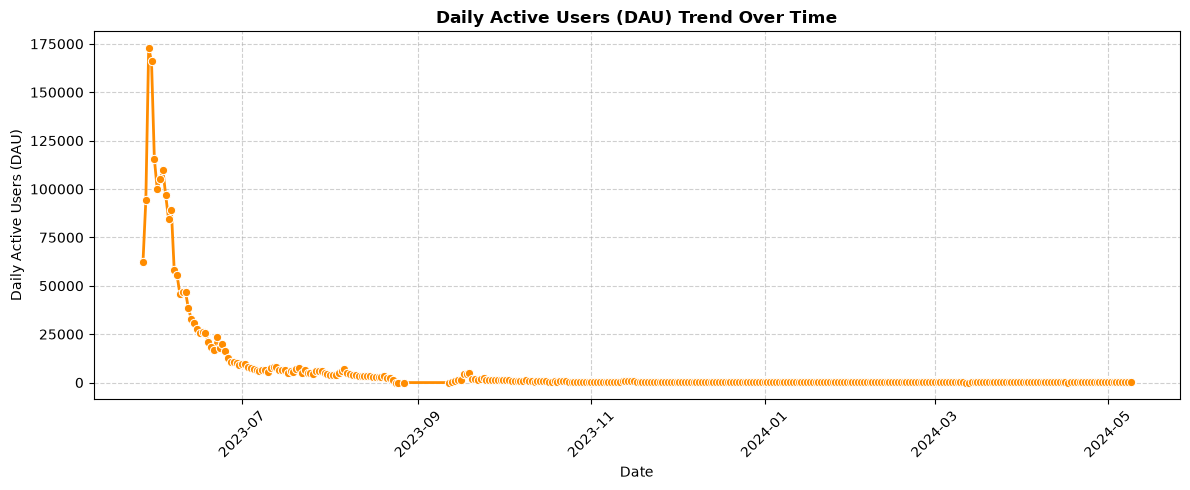

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# 일별 고유 방문자수(DAU) 데이터 확인
print('--- 최근 DAU 데이터 요약 ---')
print(daily_dau.tail(15))

# 기초 통계량 확인
print('\n--- DAU 기초 통계 ---')
print(daily_dau['dau'].describe())

# 시간 흐름에 따른 방문자수(DAU) 추이 시각화
plt.figure(figsize=(12, 5))
sns.lineplot(
    data=daily_dau,
    x='date',
    y='dau',
    marker='o',
    color='darkorange',
    linewidth=2,
)
plt.title('Daily Active Users (DAU) Trend Over Time', fontsize=12, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Daily Active Users (DAU)')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [17]:
# 2024년 4월 1일부터 2024년 5월 31일까지 필터링
start_target = pd.to_datetime('2024-04-01').date()
end_target = pd.to_datetime('2024-05-31').date()

# daily_dau의 date 타입에 맞춰 필터링
daily_target = daily_dau[
    (daily_dau['date'] >= start_target) & (daily_dau['date'] <= end_target)
]

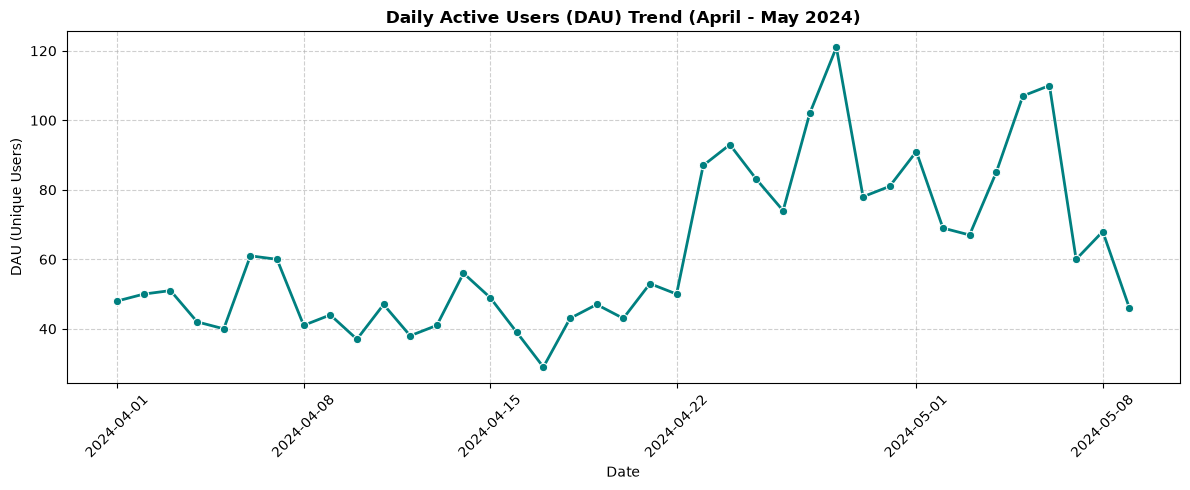

In [18]:
plt.figure(figsize=(12, 5))
sns.lineplot(
    data=daily_target,
    x='date',
    y='dau',
    marker='o',
    color='teal',
    linewidth=2,
)
plt.title(
    'Daily Active Users (DAU) Trend (April - May 2024)',
    fontsize=12,
    fontweight='bold',
)
plt.xlabel('Date')
plt.ylabel('DAU (Unique Users)')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [19]:
# daily_dau의 date 타입에 맞춰 필터링
start_target = pd.to_datetime('2024-04-22').date()
end_target = pd.to_datetime('2024-05-08').date()

daily_target = daily_dau[
    (daily_dau['date'] >= start_target) & (daily_dau['date'] <= end_target)
]

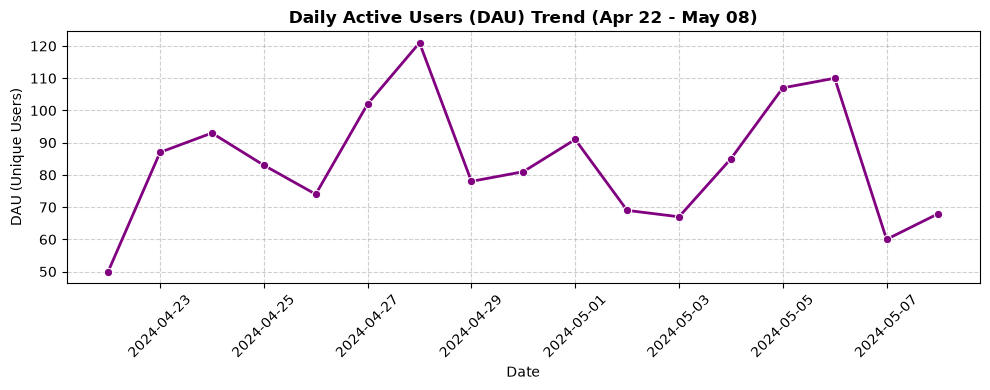

In [20]:
plt.figure(figsize=(10, 4))
sns.lineplot(
    data=daily_target,
    x='date',
    y='dau',
    marker='o',
    color='purple',
    linewidth=2,
)
plt.title(
    'Daily Active Users (DAU) Trend (Apr 22 - May 08)',
    fontsize=12,
    fontweight='bold',
)
plt.xlabel('Date')
plt.ylabel('DAU (Unique Users)')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [21]:
# 스파이크 기간 확인 및 제외
spike_start = '2024-04-23'
spike_end = '2024-05-06'

# 스파이크 기간에 발생한 이벤트/투표 기록을 제외
df_no_spike = df_merged[
    (df_merged['created_at'] < pd.to_datetime(spike_start))
    | (df_merged['created_at'] > pd.to_datetime(spike_end))
]

In [22]:
# 제외된 데이터로 유저별·경과 주차별 재집계
user_weekly_ns = (
    df_no_spike[
        (df_no_spike['days_since_signup'] >= 0)
        & (df_no_spike['weeks_since_signup'] <= 12)
    ]
    .groupby(['chosen_user_id', 'weeks_since_signup'])
    .agg(
        votes_received=('id_x', 'count'),
        interaction_partners=('user_id', 'nunique'),
    )
    .reset_index()
)

In [23]:
# 전체 유저 평균 주차별 추이 산출
weekly_trend_ns = (
    user_weekly_ns.groupby('weeks_since_signup')
    .agg(
        avg_votes_received=('votes_received', 'mean'),
        avg_interaction_partners=('interaction_partners', 'mean'),
    )
    .reset_index()
)

In [24]:
# 0주차 기준 감소율(Retention Rate) 계산
weekly_trend_ns['vote_retention_rate'] = (
    weekly_trend_ns['avg_votes_received']
    / weekly_trend_ns.loc[0, 'avg_votes_received']
) * 100
weekly_trend_ns['partner_retention_rate'] = (
    weekly_trend_ns['avg_interaction_partners']
    / weekly_trend_ns.loc[0, 'avg_interaction_partners']
) * 100

print(weekly_trend_ns)

    weeks_since_signup  avg_votes_received  avg_interaction_partners  \
0                    0           67.417791                 12.442678   
1                    1           20.332658                  6.821705   
2                    2            9.254992                  4.077456   
3                    3            5.387029                  2.827149   
4                    4            4.057697                  2.161411   
5                    5             2.89842                  1.686983   
6                    6             2.22757                  1.376708   
7                    7            1.920235                  1.283795   
8                    8            1.575458                  1.165021   
9                    9             1.56973                  1.176216   
10                  10                 1.5                  1.146078   
11                  11            1.483871                  1.130824   
12                  12            1.334107                  1.07

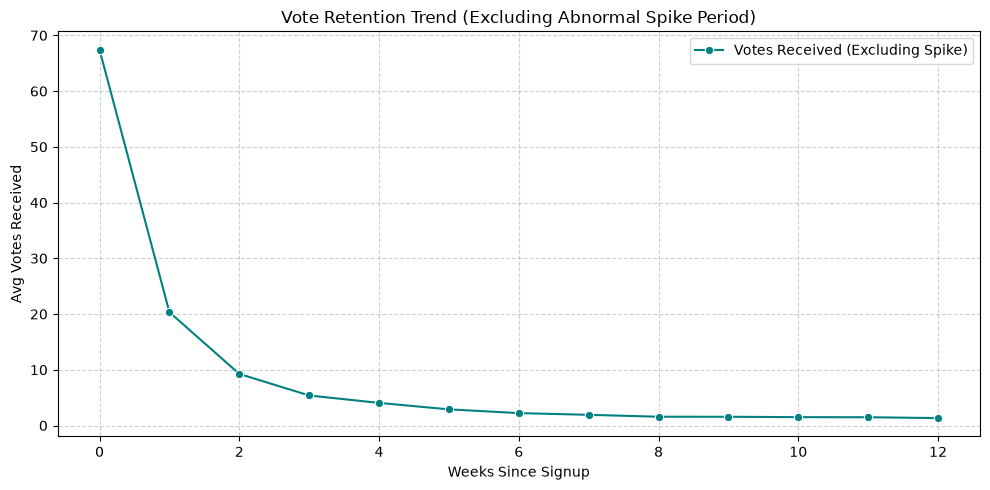

In [25]:
# 시각화 비교
plt.figure(figsize=(10, 5))
sns.lineplot(
    data=weekly_trend_ns,
    x='weeks_since_signup',
    y='avg_votes_received',
    marker='o',
    color='teal',
    label='Votes Received (Excluding Spike)',
)
plt.title(
    'Vote Retention Trend (Excluding Abnormal Spike Period)', fontsize=12
)
plt.xlabel('Weeks Since Signup')
plt.ylabel('Avg Votes Received')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

- 비정상적으로 튀는 스파이크 구간을 제외하고 분석한 결과

- 0주차에 약 67개의 높은 투표 수로 시작해 1주차(약 20개)와 2주차(약 10개 미만)에 가파르게 하락
- 4주차 이후부터는 완만하게 1~2개 수준으로 수렴하는 잔존 패턴
- 스파이크 구간을 제외하기 전 분석 결과와 큰 차이는 없는 것으로 확인

## 신고·차단 이후 활동이 감소하는가? 

In [26]:
accounts_user.head()

,id,is_superuser,is_staff,gender,point,friend_id_list,is_push_on,user_created_at,block_user_id_list,hide_user_id_list,ban_status,report_count,alarm_count,pending_chat,pending_votes,group_id
0,855284,0,0,F,5509,"[857088, 856981, 852248, 854554, 852124, 84739...",1,2023-04-29 16:13:15.312334,[],[],N,0,2,0,0,3319
1,862801,0,0,F,1515,"[858112, 853505, 852612, 853381, 853636, 85095...",1,2023-05-01 02:17:10.929300,[],[],N,0,1,0,0,3116
2,875116,0,0,F,1215,"[902016, 870790, 895369, 874250, 899721, 90459...",1,2023-05-03 09:02:41.931364,[],[],N,0,0,0,0,30
3,884169,0,0,F,271,"[911360, 898056, 945675, 987668, 942105, 99740...",1,2023-05-05 06:32:11.861364,"[1084651, 1173543]","[905750, 1090502]",N,0,0,1,0,12176
4,890678,0,0,F,4102,"[889601, 886786, 871937, 875908, 887813, 88730...",1,2023-05-05 23:43:22.667518,[],[],N,0,2,0,0,9533


In [27]:
sql = f"""
    SELECT * 
    FROM `{PROJECT_ID}.{DATA_SET}.accounts_timelinereport`
"""
accounts_timelinereport = client.query(sql).to_dataframe()
display(accounts_timelinereport.head())

/Users/youju/anaconda3/envs/pythonProject/lib/python3.11/site-packages/google/cloud/bigquery/table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,id,reason,created_at,reported_user_id,user_id,user_question_record_id
0,4794,광고,2023-05-10 14:27:44+00:00,917587,1084275,18272641
1,7168,광고,2023-05-12 14:54:46+00:00,967873,1184397,28992803
2,7169,광고,2023-05-12 14:54:52+00:00,967873,1184397,28992803
3,9998,광고,2023-05-14 16:49:58+00:00,1207784,1214760,46645583
4,10257,광고,2023-05-15 06:08:04+00:00,1250642,1228033,48820574


In [28]:
sql = f"""
    SELECT * 
    FROM `{PROJECT_ID}.{DATA_SET}.accounts_blockrecord`
"""
accounts_blockrecord = client.query(sql).to_dataframe()
display(accounts_blockrecord.head())

/Users/youju/anaconda3/envs/pythonProject/lib/python3.11/site-packages/google/cloud/bigquery/table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,id,reason,created_at,block_user_id,user_id
0,2615,나랑 관련 없는 질문을 자꾸 보냄,2023-05-09 12:55:09+00:00,1035310,1027649
1,4441,나랑 관련 없는 질문을 자꾸 보냄,2023-05-11 15:14:07+00:00,1041195,997150
2,5228,나랑 관련 없는 질문을 자꾸 보냄,2023-05-12 15:40:25+00:00,1092937,1120722
3,5627,나랑 관련 없는 질문을 자꾸 보냄,2023-05-13 06:14:48+00:00,1198311,1174030
4,6035,나랑 관련 없는 질문을 자꾸 보냄,2023-05-13 12:57:37+00:00,1032948,1044790


In [30]:
sql_hackle = f"""
    SELECT e.*, p.user_id 
    FROM `{PROJECT_ID}.{DATA_SET}.hackle_events` e
    LEFT JOIN `{PROJECT_ID}.{DATA_SET}.hackle_properties` p 
    ON e.session_id = p.session_id
"""
hackle_events = client.query(sql_hackle).to_dataframe()

/Users/youju/anaconda3/envs/pythonProject/lib/python3.11/site-packages/google/cloud/bigquery/table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


KeyboardInterrupt: 

In [ ]:
# hackle_events 기간 확인 및 날짜 변환
hackle_events['event_datetime'] = pd.to_datetime(
    hackle_events['event_datetime']
).dt.tz_localize(None)
min_date = hackle_events['event_datetime'].min()
max_date = hackle_events['event_datetime'].max()

print(f'Hackle 기간: {min_date} ~ {max_date}')

Hackle 기간: 2023-07-18 00:00:00 ~ 2023-08-10 23:59:59


In [ ]:
# 신고(timelinereport) 및 차단(blockrecord) 데이터 불러오기 및 기간 필터링
accounts_timelinereport['created_at'] = pd.to_datetime(
    accounts_timelinereport['created_at']
).dt.tz_localize(None)
accounts_blockrecord['created_at'] = pd.to_datetime(
    accounts_blockrecord['created_at']
).dt.tz_localize(None)

report_filtered = accounts_timelinereport[
    (accounts_timelinereport['created_at'] >= min_date)
    & (accounts_timelinereport['created_at'] <= max_date)
]
block_filtered = accounts_blockrecord[
    (accounts_blockrecord['created_at'] >= min_date)
    & (accounts_blockrecord['created_at'] <= max_date)
]

In [ ]:
# 유저별 최초 신고 또는 차단 시점 추출 (기준점 설정)
# 신고를 한 유저: user_id (명세서 기준)
report_events = report_filtered[['user_id', 'created_at']].rename(
    columns={'created_at': 'action_at'}
)
report_events['action_type'] = 'report'

# 차단을 한 유저: user_id (명세서 기준)
block_events = block_filtered[['user_id', 'created_at']].rename(
    columns={'created_at': 'action_at'}
)
block_events['action_type'] = 'block'

# 신고/차단 이벤트 통합
user_actions = pd.concat([report_events, block_events])
user_actions['user_id'] = user_actions['user_id'].astype(str)

In [ ]:
# hackle_events와 유저 액션 데이터 병합 (user_id 기준)
hackle_events['user_id'] = hackle_events['user_id'].astype(str)
merged_activity = pd.merge(hackle_events, user_actions, on='user_id', how='inner')

#### 차단 유저

In [ ]:
import numpy as np
import pandas as pd

# 액션 발생 전(Before)과 후(After) 구분
merged_activity['period'] = np.where(
    merged_activity['event_datetime'] < merged_activity['action_at'],
    'Before',
    'After',
)

# 이후 전후 활동량 비교 집계
activity_summary = (
    merged_activity.groupby(['user_id', 'action_type', 'period'])
    .size()
    .reset_index(name='event_count')
)

comparison = (
    activity_summary.groupby(['action_type', 'period'])['event_count']
    .mean()
    .reset_index()
)
print(comparison)

  action_type  period  event_count
0       block   After  2014.737705
1       block  Before  2251.513514


- block을 한 유저들의 평균 이벤트 발생 건수가 Before에서 After로 약 10.5% 감소
- 불쾌한 경험?을 한 유저들이 차단 조치를 취한 직후, 앱 내 전반적인 참여가 위축되는 경향을 확인

#### 신고 유저

In [ ]:
merged_report = pd.merge(hackle_events, report_events, on='user_id', how='inner')

In [ ]:
# 신고 발생 시점 기준 전(Before)과 후(After) 구분
merged_report['period'] = np.where(
    merged_report['event_datetime'] < merged_report['action_at'],
    'Before',
    'After',
)

In [ ]:
# 유저별·기간별 활동량 집계
report_activity_summary = (
    merged_report.groupby(['user_id', 'period'])
    .size()
    .reset_index(name='event_count')
)

In [ ]:
# 신고 전후 평균 활동량 비교
report_comparison = (
    report_activity_summary.groupby('period')['event_count']
    .mean()
    .reset_index()
)

print('--- 신고(Report) 액션 전후 평균 활동량 비교 ---')
print(report_comparison)

--- 신고(Report) 액션 전후 평균 활동량 비교 ---
Empty DataFrame
Columns: [period, event_count]
Index: []


In [ ]:
# 1. 신고 액션 데이터 개수 및 유저 수 확인
report_actions = user_actions[user_actions['action_type'] == 'report']
print('신고 액션 총 건수:', len(report_actions))
print('신고를 수행한 고유 유저 수:', report_actions['user_id'].nunique())

# 2. hackle_events와 유저 ID 형식 및 겹치는 유저 수 확인
print('hackle_events 유저 ID 샘플:', hackle_events['user_id'].head(3).tolist())
print('report_actions 유저 ID 샘플:', report_actions['user_id'].head(3).tolist())

common_users = set(hackle_events['user_id']).intersection(
    set(report_actions['user_id'])
)
print('두 데이터셋에서 겹치는 유저 수:', len(common_users))

신고 액션 총 건수: 0
신고를 수행한 고유 유저 수: 0
hackle_events 유저 ID 샘플: ['1011965', '1282319', '1012807']
report_actions 유저 ID 샘플: []
두 데이터셋에서 겹치는 유저 수: 0


- 신고 유저의 경우, 신고 테이블에 208행 중 hackle데이터와 엮을 수 있는게 없는 것 같다고 추정

### 차단 직전 1주일과 직후 1주일 동안의 활동량 변화

In [ ]:
# block 액션 데이터 필터링 및 시간 타입 정렬
block_actions = user_actions[user_actions['action_type'] == 'block'].copy()
block_actions['action_at'] = pd.to_datetime(block_actions['action_at'])
hackle_events['event_datetime'] = pd.to_datetime(
    hackle_events['event_datetime']
)

In [ ]:
merged_block = pd.merge(hackle_events, block_actions, on='user_id', how='inner')

In [ ]:
# 차단 시점 기준 전후 7일 이내 데이터만 필터링 
# delta_days: 이벤트 시점 - 차단 시점 (단위: 일)
merged_block['delta_days'] = (
    merged_block['event_datetime'] - merged_block['action_at']
).dt.total_seconds() / (24 * 3600)

In [ ]:
# 직전 7일 (-7 <= delta_days < 0) 및 직후 7일 (0 <= delta_days <= 7)
lagged_window = merged_block[
    (merged_block['delta_days'] >= -7) & (merged_block['delta_days'] <= 7)
].copy()

lagged_window['period_7days'] = np.where(
    lagged_window['delta_days'] < 0, 'Before_7d', 'After_7d'
)

In [ ]:
# 유저별·기간별(직전 1주일 vs 직후 1주일) 평균 일일 활동량 계산
user_lagged_summary = (
    lagged_window.groupby(['user_id', 'period_7days'])
    .size()
    .reset_index(name='event_count')
)

In [ ]:
# 1주일 기준으로 환산하기 위해 각각 7일로 나누어 일평균 활동량 비교
lagged_comparison = (
    user_lagged_summary.groupby('period_7days')['event_count']
    .mean()
    .reset_index()
)
lagged_comparison['daily_avg_events'] = lagged_comparison['event_count'] / 7.0

print('--- 차단 직전 1주일 vs 직후 1주일 일평균 활동량 비교 ---')
print(lagged_comparison[['period_7days', 'daily_avg_events']])

--- 차단 직전 1주일 vs 직후 1주일 일평균 활동량 비교 ---
  period_7days  daily_avg_events
0     After_7d        160.714286
1    Before_7d        337.043290


- 전체 기간 기준의 감소폭(약 10.5%)과 비교했을 때, 차단 전후 1주일으로 좁혀서 봤을 때 활동량 감소폭이 훨씬 극적(반토막 수준)으로 나타난다. 
- - 차단이라는 행동을 유발한 부정적 경험이나 갈등 상황이 직후에 앱 내 활동을 급격히 위축시키는 강한 트리거로 작용함

### 차단 사유별로 차단 전후 1주일 동안의 활동량 변화가 어떻게 다르게 나타나는지

In [ ]:
# 차단 기록 데이터 준비 및 user_id 타입을 문자열로 통일
block_reasons = accounts_blockrecord[
    ['user_id', 'reason', 'created_at']
].copy()
block_reasons['user_id'] = block_reasons['user_id'].astype(str)
block_reasons['action_at'] = pd.to_datetime(block_reasons['created_at'])

# hackle_events의 user_id도 문자열로 통일
hackle_events['user_id'] = hackle_events['user_id'].astype(str)
hackle_events['event_datetime'] = pd.to_datetime(
    hackle_events['event_datetime']
)

In [ ]:
# 'user_id' 기준으로 병합
merged_reason = pd.merge(
    hackle_events, block_reasons, on='user_id', how='inner'
)

In [ ]:
# 차단 시점 기준 전후 7일 필터링
merged_reason['delta_days'] = (
    merged_reason['event_datetime'] - merged_reason['action_at']
).dt.total_seconds() / (24 * 3600)

reason_window = merged_reason[
    (merged_reason['delta_days'] >= -7) & (merged_reason['delta_days'] <= 7)
].copy()

reason_window['period_7days'] = np.where(
    reason_window['delta_days'] < 0, 'Before_7d', 'After_7d'
)

In [ ]:
# 차단 사유별·유저별·기간별 이벤트 건수 집계
reason_summary = (
    reason_window.groupby(['reason', 'user_id', 'period_7days'])
    .size()
    .reset_index(name='event_count')
)

In [ ]:
# 차단 사유별 평균 일일 활동량(Before vs After) 비교 계산
reason_comparison = (
    reason_summary.groupby(['reason', 'period_7days'])['event_count']
    .mean()
    .reset_index()
)
reason_comparison['daily_avg_events'] = reason_comparison['event_count'] / 7.0

In [ ]:
# 피벗 테이블 형태로 변환하여 감소율 계산
pivot_reason = reason_comparison.pivot(
    index='reason', columns='period_7days', values='daily_avg_events'
).reset_index()

if 'Before_7d' in pivot_reason.columns and 'After_7d' in pivot_reason.columns:
  pivot_reason['drop_rate_pct'] = (
      (pivot_reason['Before_7d'] - pivot_reason['After_7d'])
      / pivot_reason['Before_7d']
  ) * 100

print('--- 차단 사유(Reason)별 전후 활동량 및 감소율 비교 ---')
display(pivot_reason)

--- 차단 사유(Reason)별 전후 활동량 및 감소율 비교 ---


period_7days,reason,After_7d,Before_7d,drop_rate_pct
0,나랑 관련 없는 질문을 자꾸 보냄,206.247619,424.020408,51.359035
1,너무 많은 양의 질문을 보냄,265.663265,394.492063,32.656880
2,모르는 사람임,79.230519,175.913043,54.960407
3,사칭 계정,37.270677,32.464286,-14.805165
4,친구 사이가 어색해짐,166.845238,380.895044,56.196532


- 친구 사이가 어색해짐 (감소율 56.2%) 및 모르는 사람임 (감소율 55.0%) 사유로 차단한 경우, 차단 직후 활동량이 절반 이상 급감하여 가장 타격이 큼
- 나랑 관련 없는 질문을 자꾸 보냄 (감소율 51.4%) 역시 높은 감소율을 보임
- 너무 많은 양의 질문을 보냄 (감소율 32.7%)은 상대적으로 완만한 감소를 보였으나 여전히 상당한 이탈
- 사칭 계정 (감소율 -14.8%)의 경우 오히려 차단 이후 활동량이 소폭 증가하는 이외의 양상이라고 생각

## 일정 기간 미활동 후 돌아온 유저는 어떤 행동을 하는가? 

In [ ]:
sql = f"""
    SELECT * 
    FROM `{PROJECT_ID}.{DATA_SET}.accounts_attendance`
"""
accounts_attendance = client.query(sql).to_dataframe()
display(accounts_attendance.head())

/Users/youju/anaconda3/envs/pythonProject/lib/python3.11/site-packages/google/cloud/bigquery/table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,id,attendance_date_list,user_id
0,7923,"[""2023-05-27"", ""2023-05-28"", ""2023-05-29"", ""20...",1355335
1,38921,"[""2023-05-27"", ""2023-05-28"", ""2023-05-29"", ""20...",892265
2,777,"[""2023-05-27"", ""2023-05-28"", ""2023-05-29"", ""20...",913054
3,6557,"[""2023-05-27"", ""2023-05-28"", ""2023-05-29"", ""20...",947077
4,2534,"[""2023-05-27"", ""2023-05-28"", ""2023-05-29"", ""20...",1233366


In [ ]:
import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [ ]:
gaps_list = []

for idx, row in accounts_attendance.iterrows():
  user_id = row['user_id']
  date_list_str = row['attendance_date_list']

  if pd.isna(date_list_str):
    continue

  try:
    dates = json.loads(date_list_str)
  except:
    continue

  if isinstance(dates, list) and len(dates) > 1:
    # 날짜순 정렬
    dt_dates = sorted([pd.to_datetime(d).date() for d in dates])

    # 연속된 출석일 사이의 공백(미활동 일수) 계산
    for i in range(len(dt_dates) - 1):
      gap = (dt_dates[i + 1] - dt_dates[i]).days - 1
      if gap > 0:  # 하루 이상 쉬고 돌아온 경우만 집계
        gaps_list.append({'user_id': user_id, 'inactivity_gap_days': gap})

df_gaps = pd.DataFrame(gaps_list)

print('--- 복귀 전 미활동 공백(일수) 기초 통계 ---')
print(df_gaps['inactivity_gap_days'].describe(percentiles=[0.5, 0.75, 0.9, 0.95]))

--- 복귀 전 미활동 공백(일수) 기초 통계 ---
count    720268.000000
mean          9.679879
std          24.233689
min           1.000000
50%           2.000000
75%           6.000000
90%          24.000000
95%          49.000000
max         344.000000
Name: inactivity_gap_days, dtype: float64


findfont: Failed to find font weight bold, now using 400.


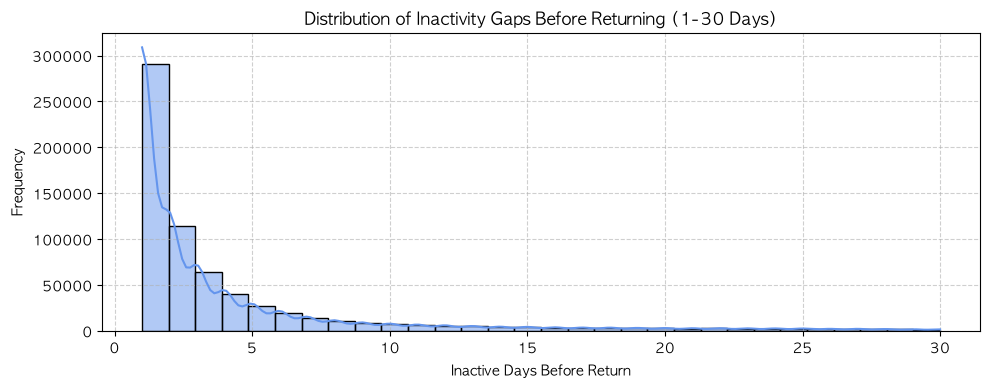

In [ ]:
plt.figure(figsize=(10, 4))
sns.histplot(
    df_gaps[df_gaps['inactivity_gap_days'] <= 30],
    x='inactivity_gap_days',
    bins=30,
    color='cornflowerblue',
    kde=True,
)
plt.title(
    'Distribution of Inactivity Gaps Before Returning (1-30 Days)',
    fontsize=12,
    fontweight='bold',
)
plt.xlabel('Inactive Days Before Return')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

- 전체 복귀 케이스의 50%가 2일 이하의 공백 후에 이루어짐
- 75%는 6일 이내에 다시 앱으로 돌아오는 강력한 단기 리인게이지먼트 성향을 보입니다.

- 평균 공백은 약 9.7일이지만, 최대 344일까지 장기 이탈했다가 돌아오는 케이스도  잇음
- 그치만 그래프를 보면 알 수 있듯이 1~3일 구간에 압도적인 빈도가 집중

#### 공백 기간 가지고 다시 복귀하는 유저

In [ ]:
# 출석 데이터로부터 공백 기간과 복귀일 매핑 데이터 구축
return_events = []

for idx, row in accounts_attendance.iterrows():
  user_id = row['user_id']
  date_list_str = row['attendance_date_list']

  if pd.isna(date_list_str):
    continue

  try:
    dates = json.loads(date_list_str)
  except:
    continue

  if isinstance(dates, list) and len(dates) > 1:
    dt_dates = sorted([pd.to_datetime(d).date() for d in dates])

    for i in range(len(dt_dates) - 1):
      gap = (dt_dates[i + 1] - dt_dates[i]).days - 1
      if gap > 0:
        return_date = dt_dates[i + 1]
        if gap <= 2:
          gap_group = '1. Short (1-2 days)'
        elif gap <= 6:
          gap_group = '2. Medium (3-6 days)'
        else:
          gap_group = '3. Long (7+ days)'

        return_events.append({
            'user_id': str(user_id),
            'return_date': return_date,
            'gap_group': gap_group,
        })

df_returns = pd.DataFrame(return_events)

In [ ]:
# hackle_events 데이터와 병합하여 복귀 당일 발생한 모든 로그 추출
hackle_events['user_id'] = hackle_events['user_id'].astype(str)
hackle_events['event_date'] = pd.to_datetime(
    hackle_events['event_datetime']
).dt.date
hackle_events['event_datetime'] = pd.to_datetime(
    hackle_events['event_datetime']
)

merged_return_events = pd.merge(
    hackle_events, df_returns, left_on=['user_id', 'event_date'], right_on=['user_id', 'return_date'], how='inner'
)

In [ ]:
# 시간순으로 정렬하여 유저별 복귀 당일 이벤트 흐름(Sequence) 번호 부여
merged_return_events = merged_return_events.sort_values(
    ['user_id', 'return_date', 'event_datetime']
)
merged_return_events['event_sequence'] = merged_return_events.groupby(
    ['user_id', 'return_date']
).cumcount() + 1

In [ ]:
# 복귀 직후 첫 번째부터 다섯 번째까지의 행동 흐름 단계별(Step 1 ~ Step 5) 집계
flow_steps = merged_return_events[merged_return_events['event_sequence'] <= 5]

flow_summary = (
    flow_steps.groupby(['gap_group', 'event_sequence', 'event_key'])
    .size()
    .reset_index(name='count')
)

In [ ]:
# 각 단계별 상위 이벤트 추출
flow_summary['rank'] = flow_summary.groupby(['gap_group', 'event_sequence'])[
    'count'
].rank(ascending=False, method='first')
top_flow = flow_summary[flow_summary['rank'] <= 3].sort_values(
    ['gap_group', 'event_sequence', 'count'], ascending=[True, True, False]
)

print('--- 복귀 공백 그룹별 복귀 직후 행동 흐름 (Step 1 ~ 5) ---')
print(
    top_flow[['gap_group', 'event_sequence', 'event_key', 'count']].to_string(
        index=False
    )
)

--- 복귀 공백 그룹별 복귀 직후 행동 흐름 (Step 1 ~ 5) ---
           gap_group  event_sequence           event_key  count
 1. Short (1-2 days)               1      $session_start   9984
 1. Short (1-2 days)               1          launch_app   8708
 1. Short (1-2 days)               1        $session_end    131
 1. Short (1-2 days)               2      $session_start   9710
 1. Short (1-2 days)               2          launch_app   8968
 1. Short (1-2 days)               2        $session_end    111
 1. Short (1-2 days)               3      $session_start   8157
 1. Short (1-2 days)               3          launch_app   7941
 1. Short (1-2 days)               3    click_attendance   1315
 1. Short (1-2 days)               4          launch_app   8294
 1. Short (1-2 days)               4      $session_start   7714
 1. Short (1-2 days)               4 click_question_open    335
 1. Short (1-2 days)               5    click_attendance   5534
 1. Short (1-2 days)               5          launch_app   41

### 탈퇴 사유와 가입 경과 구간 매칭

In [ ]:
import pandas as pd

# 가정: 유저 테이블과 탈퇴 테이블이 조인되어 있다고 가정
# df_users: user_id, created_at (가입일)
# df_withdraw: user_id, reason, created_at (탈퇴일)

df_withdraw_full = pd.merge(df_withdraw, df_users[['user_id', 'created_at']], on='user_id', suffixes=('', '_signup'))
df_withdraw_full['created_at'] = pd.to_datetime(df_withdraw_full['created_at'])
df_withdraw_full['created_at_signup'] = pd.to_datetime(df_withdraw_full['created_at_signup'])

# 가입 후 탈퇴까지 걸린 일수(Tenure Days at Withdraw) 계산
df_withdraw_full['tenure_at_withdraw'] = (df_withdraw_full['created_at'] - df_withdraw_full['created_at_signup']).dt.days

# 구간별 분류 (bins 설정)
bins = [-1, 14, 39, 69, 80, 365]
labels = ['2주 이내', '1차 피로도 구간 (16-39일)', '안정기', '2차 번아웃 구간 (70-80일)', '장기 잔존 후 이탈']
df_withdraw_full['withdraw_tenure_segment'] = pd.cut(df_withdraw_full['tenure_at_withdraw'], bins=bins, labels=labels)

# 구간별 탈퇴 사유(reason) 집계 및 교차표 생성
withdraw_reason_pivot = pd.crosstab(
    df_withdraw_full['withdraw_tenure_segment'], 
    df_withdraw_full['reason'], 
    normalize='index' # 비율로 확인
) * 100

print("--- 가입 경과 구간별 탈퇴 사유 비중 (%) ---")
print(withdraw_reason_pivot.round(2))

### 차단 사유와 탈퇴/이탈의 인과관계 검증

In [ ]:
# 차단 기록과 탈퇴 기록 조인
# accounts_blockrecord: user_id, block_user_id, reason (차단 사유), created_at (차단 시간)
# accounts_userwithdraw: user_id, created_at (탈퇴 시간)

df_block_withdraw = pd.merge(
    accounts_blockrecord, 
    accounts_userwithdraw[['user_id', 'created_at']].rename(columns={'created_at': 'withdraw_at'}), 
    on='user_id', 
    how='inner'
)

df_block_withdraw['created_at'] = pd.to_datetime(df_block_withdraw['created_at'])
df_block_withdraw['withdraw_at'] = pd.to_datetime(df_block_withdraw['withdraw_at'])

# 차단 후 탈퇴까지 걸린 시간(일 또는 시간) 계산
df_block_withdraw['hours_to_withdraw'] = (df_block_withdraw['withdraw_at'] - df_block_withdraw['created_at']).dt.total_seconds() / 3600

# 차단 직후 24시간 이내 탈퇴한 비중 확인
df_block_withdraw['withdrew_within_24h'] = df_block_withdraw['hours_to_withdraw'].between(0, 24)

# 차단 사유별 24시간 이내 탈퇴 전환율 집계
summary_block_withdraw = df_block_withdraw.groupby('reason').agg(
    total_blocked_users=('user_id', 'nunique'),
    withdrew_within_24h_count=('withdrew_within_24h', 'sum')
).reset_index()

summary_block_withdraw['withdraw_rate_24h_pct'] = (
    summary_block_withdraw['withdrew_within_24h_count'] / summary_block_withdraw['total_blocked_users']
) * 100

print("--- 차단 사유별 직후 24시간 이내 탈퇴 전환율 ---")
print(summary_block_withdraw.sort_values(by='withdraw_rate_24h_pct', ascending=False).to_string(index=False))

### 복귀 직후 세션 불안정성 ($session_end 반복) 패턴 분석

In [ ]:
# 앞서 구한 복귀 유저 데이터(df_returns)와 hackle_events 결합
# df_returns: user_id, return_date, gap_group (Short, Medium, Long)

merged_sessions = pd.merge(
    hackle_events[hackle_events['event_key'].isin(['$session_start', '$session_end'])],
    df_returns,
    left_on=['user_id', 'event_date'],
    right_on=['user_id', 'return_date'],
    how='inner'
)

# 복귀 당일 첫 세션에서의 이벤트 시퀀스 정렬
merged_sessions = merged_sessions.sort_values(['user_id', 'return_date', 'event_datetime'])
merged_sessions['seq'] = merged_sessions.groupby(['user_id', 'return_date']).cumcount() + 1

# 복귀 직후 첫 2개 이벤트($session_start 바로 다음에 $session_end가 오는 케이스) 필터링
first_events = merged_sessions[merged_sessions['seq'] <= 2].pivot_table(
    index=['user_id', 'return_date', 'gap_group'],
    columns='seq',
    values='event_key',
    aggfunc='first'
).reset_index()

first_events.columns = ['user_id', 'return_date', 'gap_group', 'first_event', 'second_event']

# 그룹별(Short vs Long) 복귀 직후 곧바로 종료($session_end)되는 비율 계산
crash_analysis = first_events.groupby('gap_group').agg(
    total_returns=('user_id', 'count'),
    immediate_end_count=('second_event', lambda x: (x == '$session_end').sum())
).reset_index()

crash_analysis['immediate_end_rate_pct'] = (
    crash_analysis['immediate_end_count'] / crash_analysis['total_returns']
) * 100

print("--- 복귀 공백 그룹별 직후 즉시 세션 종료율 (크래시 의심) ---")
print(crash_analysis.to_string(index=False))


### 앱 버전별 세션 종료율 비교

In [ ]:
sql = f"""
    SELECT * 
    FROM `{PROJECT_ID}.{DATA_SET}.hackle_properties`
"""
hackle_properties = client.query(sql).to_dataframe()
display(hackle_properties.head())

/Users/youju/anaconda3/envs/pythonProject/lib/python3.11/site-packages/google/cloud/bigquery/table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,id,session_id,user_id,language,osname,osversion,versionname,device_id
0,224502,Wd0uIgJhG8dYFjb321m9wd2FFXg2,857358,ko,Android,10,1.2.19,d9b90d48-bad9-4c7f-a402-f699d86c5dec
1,469325,xwom0ehJEuNbDx7ApxBEFnZGPoJ2,878777,ko,Android,10,1.2.19,bd9addf2-eb15-4980-825c-7e197d40478b
2,453926,GEpExuLdNKeutVyA84xr4bJDCpl1,863094,ko,Android,10,1.2.19,dbf1c67c-76b8-4ac5-967f-40b8e2af2e3d
3,455322,Z9bf8zoKT7d7Sq3q5KvhvNEJ1RK2,889361,ko,Android,10,1.2.19,835555c2-6b20-46ce-abdc-c0795fdb79c7
4,335299,33A2PMwZcjPwzMBuILGHPotw1x12,842950,ko,Android,10,1.2.19,b15c645d-5bb6-4abf-9b0f-b97c072d753a


--- 앱 버전별 세션 시작/종료 및 종료율 통계 ---
versionname  $session_end  $session_start  session_end_ratio
      2.0.5       1191898         1740614           0.684757
      2.0.3       1001976         1392427           0.719590
      2.0.0        298695          417859           0.714822
     1.2.19          5660           10057           0.562792
      1.2.8             9              12           0.750000


/var/folders/t0/85xt099562dflgf6nvxdqgl00000gn/T/ipykernel_4361/408822271.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(
findfont: Failed to find font weight bold, now using 400.


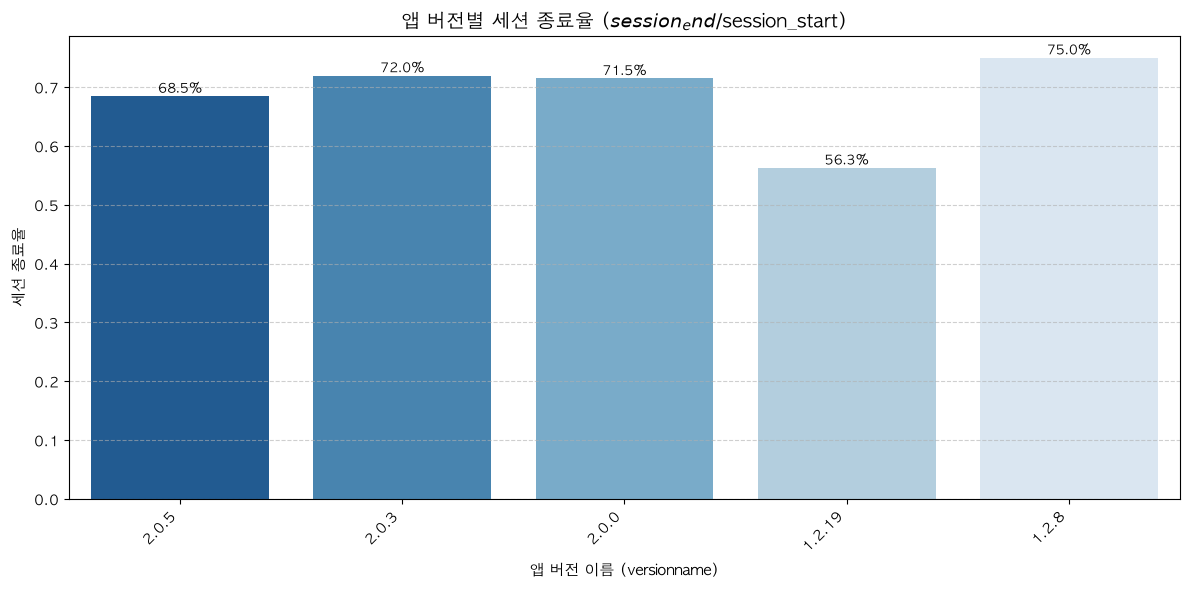

: 

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 환경별 한글 폰트 설정
import platform
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin':
    plt.rc('font', family='AppleGothic')
else:
    plt.rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False

# 가정: hackle_events와 hackle_properties 데이터프레임이 이미 로드되어 있다고 가정
# hackle_events: ['user_id', 'session_id', 'event_key', 'event_datetime', ...]
# hackle_properties: ['session_id', 'user_id', 'versionname', 'osname', ...]

# 세션 프로퍼티에서 세션별 앱 버전 매핑 데이터 생성 (중복 제거)
session_version = hackle_properties[['session_id', 'versionname']].drop_duplicates()

# 이벤트 데이터와 앱 버전 정보 병합
df_events_with_version = pd.merge(hackle_events, session_version, on='session_id', how='inner')

# 버전별 $session_start와 $session_end 이벤트 집계
version_session_counts = df_events_with_version[
    df_events_with_version['event_key'].isin(['$session_start', '$session_end'])
].groupby(['versionname', 'event_key']).size().unstack(fill_value=0)

# 컬럼 안전 장치 ($session_start, $session_end 가 모두 존재하는지 확인)
if '$session_start' in version_session_counts.columns and '$session_end' in version_session_counts.columns:
    # 4. 세션 종료율 계산 ($session_end / $session_start)
    version_session_counts['session_end_ratio'] = (
        version_session_counts['$session_end'] / version_session_counts['$session_start']
    )
    
    # 데이터 정렬 (시작 세션 수 기준 내림차순 또는 버전명 기준)
    version_session_counts = version_session_counts.reset_index().sort_values(by='$session_start', ascending=False)
    
    print('--- 앱 버전별 세션 시작/종료 및 종료율 통계 ---')
    print(version_session_counts.to_string(index=False))

    # 5. 시각화 (버전별 세션 종료율 바 차트)
    plt.figure(figsize=(12, 6))
    ax = sns.barplot(
        data=version_session_counts,
        x='versionname',
        y='session_end_ratio',
        palette='Blues_r'
    )
    
    plt.title('앱 버전별 세션 종료율 ($session_end / $session_start)', fontsize=14, fontweight='bold')
    plt.xlabel('앱 버전 이름 (versionname)', fontsize=11)
    plt.ylabel('세션 종료율', fontsize=11)
    plt.xticks(rotation=45, ha='right')
    plt.grid(True, axis='y', linestyle='--', alpha=0.6)
    
    # 바 위에 퍼센트 수치 표기
    for p in ax.patches:
        height = p.get_height()
        if height > 0:
            ax.annotate(f'{height * 100:.1f}%',
                        (p.get_x() + p.get_width() / 2., height),
                        ha='center', va='center',
                        xytext=(0, 5),
                        textcoords='offset points',
                        fontsize=9)
            
    plt.tight_layout()
    plt.show()
else:
    print("데이터 내에 '$session_start' 또는 '$session_end' 이벤트 키가 존재하지 않습니다.")

#### 어느정도 이 앱을 사용한 사람이 이런 공백기를 가지게 될까

In [ ]:
# 유저 가입일 데이터 준비 (accounts_user 테이블 가정)
# user_id와 가입일(created_at 또는 signup_date) 컬럼 활용
users_signup = accounts_user[['id', 'created_at']].copy()
users_signup = users_signup.rename(columns={'id': 'user_id'})
users_signup['user_id'] = users_signup['user_id'].astype(str)
users_signup['signup_date'] = pd.to_datetime(
    users_signup['created_at']
).dt.date

In [ ]:
# 출석 데이터 기반 공백 발생 시점 추출
gap_tenure_list = []

for idx, row in accounts_attendance.iterrows():
  user_id = str(row['user_id'])
  date_list_str = row['attendance_date_list']

  if pd.isna(date_list_str):
    continue

  try:
    dates = json.loads(date_list_str)
  except:
    continue

  if isinstance(dates, list) and len(dates) > 1:
    dt_dates = sorted([pd.to_datetime(d).date() for d in dates])

    for i in range(len(dt_dates) - 1):
      gap = (dt_dates[i + 1] - dt_dates[i]).days - 1
      if gap > 0:
        inactivity_start_date = dt_dates[i]  # 공백이 시작된 날짜
        gap_tenure_list.append({
            'user_id': user_id,
            'inactivity_start_date': inactivity_start_date,
            'gap_days': gap,
        })

df_gaps_all = pd.DataFrame(gap_tenure_list)

In [ ]:
# 유저 가입일과 병합하여 '가입 후 경과 일수(Tenure)' 계산
df_gaps_with_signup = pd.merge(df_gaps_all, users_signup, on='user_id', how='inner')
df_gaps_with_signup['tenure_days_at_gap'] = (
    pd.to_datetime(df_gaps_with_signup['inactivity_start_date'])
    - pd.to_datetime(df_gaps_with_signup['signup_date'])
).dt.days

In [ ]:
# 가입 후 경과 기간 구간별 공백(Inactivity Gap) 발생 빈도 집계
print('--- 가입 후 경과 시점(Tenure)별 공백 발생 현황 요약 ---')
print(
    df_gaps_with_signup['tenure_days_at_gap'].describe(
        percentiles=[0.25, 0.5, 0.75, 0.9]
    )
)

--- 가입 후 경과 시점(Tenure)별 공백 발생 현황 요약 ---
count    720268.000000
mean         34.255919
std          33.014280
min           0.000000
25%          16.000000
50%          24.000000
75%          39.000000
90%          72.000000
max         378.000000
Name: tenure_days_at_gap, dtype: float64


findfont: Failed to find font weight bold, now using 400.


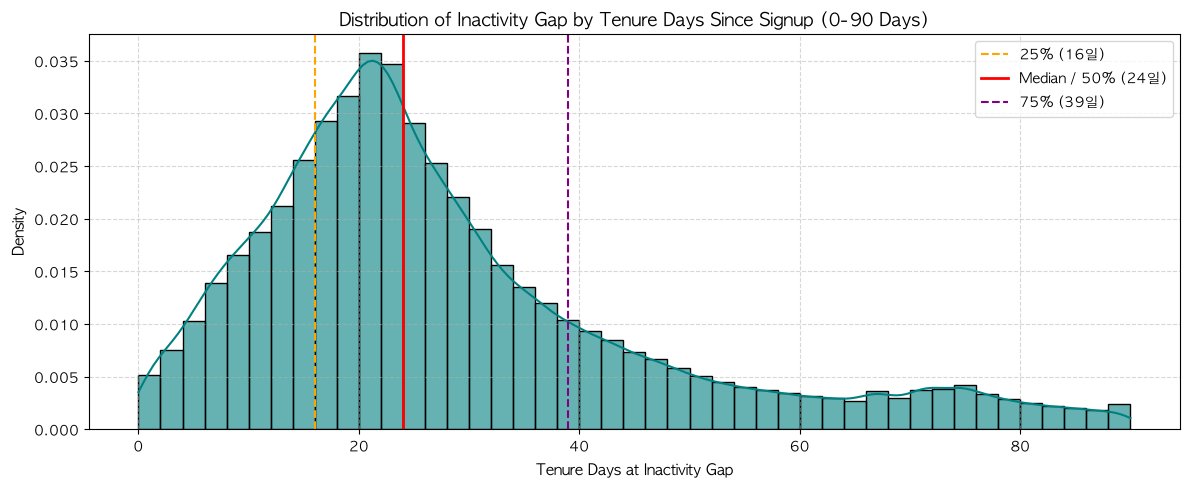

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 5))

# 히스토그램 및 KDE 플롯 (90% 구간인 0~90일 위주로 상세 표현, 혹은 전체 데이터로 조정 가능)
# 90% 구간(72일)을 고려하여 x축 범위를 0~90일로 포커싱 (필요 시 max까지 확장 가능)
plot_data = df_gaps_with_signup[
    (df_gaps_with_signup['tenure_days_at_gap'] >= 0)
    & (df_gaps_with_signup['tenure_days_at_gap'] <= 90
    )  # 90일 이내 집중 구간
]

sns.histplot(
    plot_data['tenure_days_at_gap'],
    bins=45,
    kde=True,
    color='teal',
    stat='density',
    alpha=0.6,
)

# 주요 백분위수(25%, 50%, 75%) 수직선 표시로 가독성 높이기
p25 = df_gaps_with_signup['tenure_days_at_gap'].quantile(0.25)
p50 = df_gaps_with_signup['tenure_days_at_gap'].quantile(0.50)
p75 = df_gaps_with_signup['tenure_days_at_gap'].quantile(0.75)

plt.axvline(
    p25, color='orange', linestyle='--', linewidth=1.5, label=f'25% (16일)'
)
plt.axvline(
    p50, color='red', linestyle='-', linewidth=2, label=f'Median / 50% (24일)'
)
plt.axvline(
    p75, color='purple', linestyle='--', linewidth=1.5, label=f'75% (39일)'
)

plt.title(
    'Distribution of Inactivity Gap by Tenure Days Since Signup (0-90 Days)',
    fontsize=13,
    fontweight='bold',
)
plt.xlabel('Tenure Days at Inactivity Gap', fontsize=11)
plt.ylabel('Density', fontsize=11)
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

#### 가입 후 특정 경과 시점대별로 유저들이 겪는 공백기의 길이

In [ ]:
# 가입 후 경과 시점(Tenure)을 구간별로 분류
# 예: 0~2주, 2~4주, 1~2달, 2달 이상 등
bins = [-1, 14, 30, 60, 90, 365]
labels = [
    '1. 2주 이내 (0-14일)',
    '2. 2~4주 (15-30일)',
    '3. 1~2달 (31-60일)',
    '4. 2~3달 (61-90일)',
    '5. 3달 이후 (90일+)',
]
df_gaps_with_signup['tenure_segment'] = pd.cut(
    df_gaps_with_signup['tenure_days_at_gap'], bins=bins, labels=labels
)

In [ ]:
# 가입 시기별 공백 기간의 기초 통계량 (평균, 중앙값 등) 요약
gap_by_tenure = (
    df_gaps_with_signup.groupby('tenure_segment')['gap_days']
    .agg(
        count='count',
        mean_gap='mean',
        median_gap='median',
        p75_gap=lambda x: x.quantile(0.75),
        p90_gap=lambda x: x.quantile(0.90),
    )
    .reset_index()
)

print('--- 가입 시기(Tenure) 구간별 공백기(일수) 통계 ---')
print(gap_by_tenure.to_string(index=False))

--- 가입 시기(Tenure) 구간별 공백기(일수) 통계 ---
  tenure_segment  count  mean_gap  median_gap  p75_gap  p90_gap
1. 2주 이내 (0-14일) 144605  5.631645         1.0      3.0      7.0
2. 2~4주 (15-30일) 315060  7.997680         2.0      4.0     16.0
3. 1~2달 (31-60일) 164401 11.646943         3.0     10.0     29.0
4. 2~3달 (61-90일)  58406 17.024398         4.0     14.0     54.0
 5. 3달 이후 (90일+)  37784 19.290626         5.0     25.0     54.0


/var/folders/t0/85xt099562dflgf6nvxdqgl00000gn/T/ipykernel_4361/1784599782.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


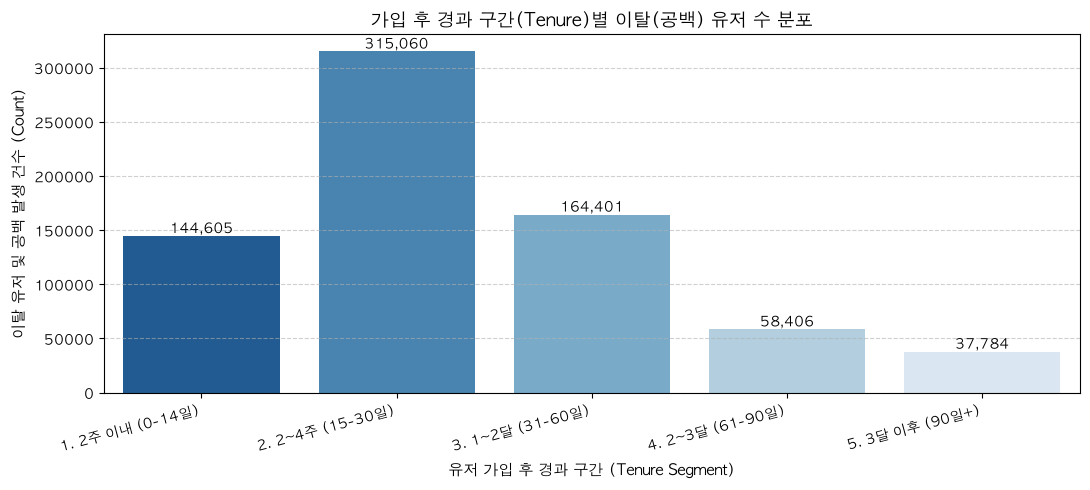

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import platform

# 환경별 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin':
    plt.rc('font', family='AppleGothic')
else:
    plt.rc('font', family='NanumGothic')

plt.rcParams['axes.unicode_minus'] = False

# 그래프 생성: 구간별 이탈/공백 건수(count) 시각화
plt.figure(figsize=(11, 5))

ax = sns.barplot(
    data=gap_by_tenure,
    x='tenure_segment',
    y='count',
    palette='Blues_r'  # 데이터 분포가 눈에 잘 띄는 팔레트
)

plt.title('가입 후 경과 구간(Tenure)별 이탈(공백) 유저 수 분포', fontsize=13, fontweight='bold')
plt.xlabel('유저 가입 후 경과 구간 (Tenure Segment)', fontsize=11)
plt.ylabel('이탈 유저 및 공백 발생 건수 (Count)', fontsize=11)
plt.xticks(rotation=15, ha='right')
plt.grid(True, axis='y', linestyle='--', alpha=0.6)

# 각 바 위에 정확한 수치(count) 표기
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', 
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', 
                xytext=(0, 5), 
                textcoords='offset points',
                fontsize=10)

plt.tight_layout()
plt.show()

- 가입 후 서비스 이용 기간이 길어질수록, 유저들이 이탈 후 쉬다 돌아오는 **공백기의 길이도 비례해서 길어지는** 뚜렷한 우상향 패턴
- 평균 공백은 6~8일 수준이지만 **중앙값은 1~2일**에 불과함
    - 가입 직후 이탈하는 유저는 가볍게 앱을 닫았다가 금방 다시 돌아옴
- 시간이 지날수록 평균 공백과 중앙값이 함께 가파르게 상승하며, 특히 **3달 이후 구간**에서는 평균 공백이 약 19일, 중앙값도 **5일에 달함**
- 서비스에 깊이 정착했던 유저들이 공백기를 가질 때는 훨씬 더 오래 쉬다가 복귀하거나 영구 이탈로 이어질 확률이 높음
    - 가입 초기 유저와 장기 유저의 이탈 시점에 맞춘 맞춤형 리인게이지먼트 타이밍(예: 장기 유저는 3~5일 차에 선제적 타겟 푸시)을 다르게 가져갈 필요가 있음

### 가입 후 3~4주 차에 잔존한 '코어 유저'와 이탈한 '일반 유저'를 나누고, 이들의 가입 첫 주 행동량 비교

In [ ]:
sql_hackle = f"""
    SELECT e.*, p.user_id 
    FROM `{PROJECT_ID}.{DATA_SET}.hackle_events` e
    LEFT JOIN `{PROJECT_ID}.{DATA_SET}.hackle_properties` p 
    ON e.session_id = p.session_id
"""
hackle_events = client.query(sql_hackle).to_dataframe()

/Users/youju/anaconda3/envs/pythonProject/lib/python3.11/site-packages/google/cloud/bigquery/table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


In [ ]:
# 날짜 타입 변환
accounts_user['created_at'] = pd.to_datetime(accounts_user['created_at'])
hackle_events['event_datetime'] = pd.to_datetime(hackle_events['event_datetime'])

In [ ]:
# 두 테이블의 기준 키(Key)를 모두 문자열(str)로 변환하여 타입 통일
hackle_events['user_id'] = hackle_events['user_id'].astype(str)
accounts_user['id'] = accounts_user['id'].astype(str)

# 유저 정보와 이벤트 병합 및 가입 후 경과일(tenure_days) 계산 
merged = hackle_events.merge(accounts_user[['id', 'created_at']], left_on='user_id', right_on='id', how='inner')
merged['tenure_days'] = (merged['event_datetime'] - merged['created_at']).dt.days

In [ ]:
# 유저 라벨링: 3~4주차(15~28일)에 이벤트를 1회 이상 발생시킨 유저를 '코어 유저'로 정의
core_users = merged[(merged['tenure_days'] >= 15) & (merged['tenure_days'] <= 28)]['user_id'].unique()
accounts_user['user_group'] = np.where(accounts_user['id'].isin(core_users), 'Core (Retained)', 'Churned')

In [ ]:
# 가입 첫 주(0~7일) 이벤트만 필터링하여 유저별/이벤트별 발생 횟수 피벗테이블 생성
week1_events = merged[(merged['tenure_days'] >= 0) & (merged['tenure_days'] <= 7)]
week1_pivot = week1_events.pivot_table(
    index='user_id', 
    columns='event_key', 
    values='event_datetime', 
    aggfunc='count', 
    fill_value=0
)

In [ ]:
# 그룹별 '가입 첫 주 평균 행동 횟수' 비교
aha_moment_df = week1_pivot.merge(accounts_user[['id', 'user_group']], left_on='user_id', right_on='id', how='right').fillna(0)
aha_summary = aha_moment_df.groupby('user_group').mean(numeric_only=True).T
display(aha_summary) # 여기서 Core 유저와 Churned 유저 간 횟수 차이가 가장 큰 이벤트가 아하 모먼트 후보입니다.

user_group,Churned,Core (Retained)
$session_end,0.009600,25.089479
$session_start,0.010901,25.440511
click_appbar_alarm_center,0.002833,12.071780
click_appbar_chat_rooms,0.002756,9.176008
click_appbar_friend_plus,0.001361,2.159292
click_appbar_setting,0.000593,0.720747
click_attendance,0.001203,2.711898
click_autoadd_contact,0.000104,0.115044
click_bottom_navigation_lab,0.005013,6.300885
click_bottom_navigation_profile,0.009776,23.913471


### 차단 행동 직후 유저가 앱을 떠나는지(이탈), 아니면 지속해서 사용하는지

In [ ]:
sql = f"""
    SELECT * 
    FROM `{PROJECT_ID}.{DATA_SET}.accounts_blockrecord`
"""
accounts_blockrecord = client.query(sql).to_dataframe()
display(accounts_blockrecord.head())

/Users/youju/anaconda3/envs/pythonProject/lib/python3.11/site-packages/google/cloud/bigquery/table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,id,reason,created_at,block_user_id,user_id
0,2615,나랑 관련 없는 질문을 자꾸 보냄,2023-05-09 12:55:09+00:00,1035310,1027649
1,4441,나랑 관련 없는 질문을 자꾸 보냄,2023-05-11 15:14:07+00:00,1041195,997150
2,5228,나랑 관련 없는 질문을 자꾸 보냄,2023-05-12 15:40:25+00:00,1092937,1120722
3,5627,나랑 관련 없는 질문을 자꾸 보냄,2023-05-13 06:14:48+00:00,1198311,1174030
4,6035,나랑 관련 없는 질문을 자꾸 보냄,2023-05-13 12:57:37+00:00,1032948,1044790


In [ ]:
# 시계열 데이터를 Date 형식으로 변환 (시간 단위 무시하고 일 단위 계산)
accounts_blockrecord['block_date'] = pd.to_datetime(accounts_blockrecord['created_at']).dt.date

In [ ]:
# 두 테이블의 'user_id' 컬럼 데이터 타입을 문자열(str)로 통일
hackle_events['user_id'] = hackle_events['user_id'].astype(str)
accounts_blockrecord['user_id'] = accounts_blockrecord['user_id'].astype(str)

# 차단 기록과 이벤트 기록 병합
block_events = hackle_events.merge(accounts_blockrecord[['user_id', 'block_date', 'reason']], on='user_id', how='inner')

In [ ]:
# 시간을 정규화하고, 타임존(tz) 정보를 제거하여 두 컬럼의 형식을 완전히 통일
block_events['event_date'] = pd.to_datetime(block_events['event_datetime']).dt.normalize().dt.tz_localize(None)
block_events['block_date'] = pd.to_datetime(block_events['block_date']).dt.normalize().dt.tz_localize(None)

# 차단일 기준 이후 며칠 동안 활동했는지 계산 (정상 작동)
block_events['days_since_block'] = (block_events['event_date'] - block_events['block_date']).dt.days
post_block_events = block_events[block_events['days_since_block'] >= 0]

In [ ]:
# 유저별 차단 이후 '마지막 활동일' 도출
retention_after_block = post_block_events.groupby(['reason', 'user_id'])['days_since_block'].max().reset_index()

In [ ]:
# 차단 이후 7일 미만으로 활동하고 멈췄다면 '완전 이탈(True)'로 간주
retention_after_block['is_churned'] = np.where(retention_after_block['days_since_block'] < 7, True, False)

In [ ]:
# 차단 사유별 최종 이탈률 산출
churn_rate_by_reason = retention_after_block.groupby('reason')['is_churned'].mean() * 100
display(churn_rate_by_reason)

NameError: name 'retention_after_block' is not defined

### 복귀 유저 세션 내 전환율 분석

In [ ]:
# 세션 내 이벤트 순서를 정확히 알기 위해 시간순 정렬
df_events = hackle_events.sort_values(['user_id', 'session_id', 'event_datetime'])

In [ ]:
# 단순 앱 구동(session_start 등)을 제외한 실질적 첫 행동(Entry Point) 추출
entry_events_list = ['click_attendance', 'view_timeline_tap', 'click_question_open', 'click_bottom_navigation_lab']
first_actions = df_events[df_events['event_key'].isin(entry_events_list)].drop_duplicates(subset=['user_id', 'session_id'], keep='first')

In [ ]:
# 동일 세션 내에서 질문 완료(complete_question) 이벤트가 있었는지 확인
conversions = df_events[df_events['event_key'] == 'complete_question'].drop_duplicates(subset=['user_id', 'session_id'])
conversions['is_converted'] = 1

In [ ]:
# 첫 행동 데이터에 전환 여부(is_converted) Left Join
session_analysis = first_actions[['user_id', 'session_id', 'event_key']].merge(
    conversions[['session_id', 'is_converted']], 
    on='session_id', 
    how='left'
)
session_analysis['is_converted'] = session_analysis['is_converted'].fillna(0)

In [ ]:
# 진입점별 최종 전환율 도출
conversion_rate = session_analysis.groupby('event_key')['is_converted'].agg(['count', 'mean'])
conversion_rate['mean'] = conversion_rate['mean'] * 100
conversion_rate.rename(columns={'count': '세션 수', 'mean': '전환율(%)'}, inplace=True)
print(conversion_rate)

                              세션 수     전환율(%)
event_key                                    
click_attendance             12740  41.695447
click_bottom_navigation_lab  30939  23.753192
click_question_open          56658  32.609693
view_timeline_tap            96807  17.906763


### activation율

In [4]:
sql_query = """
WITH UserFirstQuestion AS (
    -- 유저별로 가장 처음 생성한 질문 세트 1건만 추출
    SELECT 
        user_id,
        status,
        ROW_NUMBER() OVER(PARTITION BY user_id ORDER BY created_at ASC) as rn
    FROM `your_project_id.your_dataset_id.polls_questionset`
)
SELECT 
    -- BigQuery 날짜 추출 포맷
    FORMAT_DATE('%Y-%m', DATE(u.created_at)) AS signup_month, 
    
    COUNT(u.id) AS total_users,
    COUNT(q.user_id) AS started_first_q,
    SUM(CASE WHEN q.status = 'F' THEN 1 ELSE 0 END) AS finished_first_q,
    
    -- Activation 퍼센티지 계산 (분모 0 방지 및 소수점 처리)
    ROUND(SAFE_DIVIDE(COUNT(q.user_id), COUNT(u.id)) * 100, 2) AS start_rate_pct,
    ROUND(SAFE_DIVIDE(SUM(CASE WHEN q.status = 'F' THEN 1 ELSE 0 END), COUNT(u.id)) * 100, 2) AS finish_rate_pct
    
FROM `your_project_id.your_dataset_id.accounts_user` u
LEFT JOIN UserFirstQuestion q 
    ON u.id = q.user_id AND q.rn = 1
-- BigQuery ROLLUP 문법 (Overall/합계 행은 signup_month가 NULL로 출력됨)
GROUP BY ROLLUP(signup_month)
ORDER BY signup_month ASC;
"""

# 4. 쿼리 실행 및 데이터프레임 변환
try:
    df = client.query(sql_query).to_dataframe()
    
    # ROLLUP으로 인해 생성된 NULL 값을 'Overall'(전체)로 치환
    df['signup_month'] = df['signup_month'].fillna('Overall')
    
    # 결과 확인
    print(df)
    
except Exception as e:
    print(f"BigQuery 실행 중 오류 발생: {e}")

BigQuery 실행 중 오류 발생: 400 Invalid project ID 'your_project_id'. Project IDs must contain 6-63 lowercase letters, digits, or dashes. Some project IDs also include domain name separated by a colon. IDs must start with a letter and may not end with a dash.; reason: invalid, location: your_project_id.your_dataset_id.accounts_user, message: Invalid project ID 'your_project_id'. Project IDs must contain 6-63 lowercase letters, digits, or dashes. Some project IDs also include domain name separated by a colon. IDs must start with a letter and may not end with a dash.

Location: US
Job ID: 0841f2de-788d-4aa2-b46d-a8dcd12e3a70



In [5]:
sql_query = f"""
WITH UserFirstQuestion AS (
    -- 유저별로 가장 처음 생성한 질문 세트 1건만 추출
    SELECT 
        user_id,
        status,
        ROW_NUMBER() OVER(PARTITION BY user_id ORDER BY created_at ASC) as rn
    FROM `{PROJECT_ID}.{DATA_SET}.polls_questionset`
)
SELECT 
    -- BigQuery 날짜 추출 포맷
    FORMAT_DATE('%Y-%m', DATE(u.created_at)) AS signup_month, 
    
    COUNT(u.id) AS total_users,
    COUNT(q.user_id) AS started_first_q,
    SUM(CASE WHEN q.status = 'F' THEN 1 ELSE 0 END) AS finished_first_q,
    
    -- Activation 퍼센티지 계산 (분모 0 방지 및 소수점 처리)
    ROUND(SAFE_DIVIDE(COUNT(q.user_id), COUNT(u.id)) * 100, 2) AS start_rate_pct,
    ROUND(SAFE_DIVIDE(SUM(CASE WHEN q.status = 'F' THEN 1 ELSE 0 END), COUNT(u.id)) * 100, 2) AS finish_rate_pct
    
FROM `{PROJECT_ID}.{DATA_SET}.accounts_user` u
LEFT JOIN UserFirstQuestion q 
    ON u.id = q.user_id AND q.rn = 1
-- BigQuery ROLLUP 문법 (Overall/합계 행은 signup_month가 NULL로 출력됨)
GROUP BY ROLLUP(signup_month)
ORDER BY signup_month ASC
"""
activation = client.query(sql_query).to_dataframe()

/Users/youju/anaconda3/envs/pythonProject/lib/python3.11/site-packages/google/cloud/bigquery/table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


In [9]:
sql = f"""
    SELECT * 
    FROM `{PROJECT_ID}.{DATA_SET}.accounts_user`
"""
df_users = client.query(sql).to_dataframe()
display(df_users.head())

/Users/youju/anaconda3/envs/pythonProject/lib/python3.11/site-packages/google/cloud/bigquery/table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,id,is_superuser,is_staff,gender,point,friend_id_list,is_push_on,created_at,block_user_id_list,hide_user_id_list,ban_status,report_count,alarm_count,pending_chat,pending_votes,group_id
0,855284,0,0,F,5509,"[857088, 856981, 852248, 854554, 852124, 84739...",1,2023-04-29 16:13:15.312334+00:00,[],[],N,0,2,0,0,3319
1,862801,0,0,F,1515,"[858112, 853505, 852612, 853381, 853636, 85095...",1,2023-05-01 02:17:10.929300+00:00,[],[],N,0,1,0,0,3116
2,875116,0,0,F,1215,"[902016, 870790, 895369, 874250, 899721, 90459...",1,2023-05-03 09:02:41.931364+00:00,[],[],N,0,0,0,0,30
3,884169,0,0,F,271,"[911360, 898056, 945675, 987668, 942105, 99740...",1,2023-05-05 06:32:11.861364+00:00,"[1084651, 1173543]","[905750, 1090502]",N,0,0,1,0,12176
4,890678,0,0,F,4102,"[889601, 886786, 871937, 875908, 887813, 88730...",1,2023-05-05 23:43:22.667518+00:00,[],[],N,0,2,0,0,9533


In [7]:
sql = f"""
    SELECT * 
    FROM `{PROJECT_ID}.{DATA_SET}.polls_questionset`
"""
df_qs = client.query(sql).to_dataframe()
display(df_qs.head())

/Users/youju/anaconda3/envs/pythonProject/lib/python3.11/site-packages/google/cloud/bigquery/table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,id,question_piece_id_list,opening_time,status,created_at,user_id
0,7993167,"[79931958, 79931960, 79931962, 79931966, 79931...",2023-05-17 00:22:16+00:00,C,2023-05-16 23:42:16+00:00,841333
1,8298931,"[82989582, 82989587, 82989592, 82989596, 82989...",2023-05-17 09:54:57+00:00,C,2023-05-17 09:14:57+00:00,845326
2,20617202,"[206172781, 206172782, 206172783, 206172784, 2...",2023-07-29 16:13:18+00:00,C,2023-07-29 15:33:18+00:00,847375
3,20017608,"[200176841, 200176842, 200176843, 200176844, 2...",2023-06-16 15:13:10+00:00,C,2023-06-16 14:33:10+00:00,849438
4,20673673,"[206737491, 206737492, 206737493, 206737494, 2...",2023-08-10 09:20:44+00:00,C,2023-08-10 08:40:44+00:00,849451


In [10]:
# 1. 유저 가입월(Month) 컬럼 생성
df_users['signup_month'] = pd.to_datetime(df_users['created_at']).dt.to_period('M')

/var/folders/t0/85xt099562dflgf6nvxdqgl00000gn/T/ipykernel_13409/1643800734.py:2: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_users['signup_month'] = pd.to_datetime(df_users['created_at']).dt.to_period('M')


In [11]:
# 2. 유저별 최초 질문 세트 추출 (시간순 정렬 후 첫 번째 행만 유지)
first_qs = df_qs.sort_values(by=['user_id', 'created_at']).drop_duplicates(subset=['user_id'], keep='first')

In [12]:
# 3. 가입자 테이블에 최초 질문 세트 데이터 병합 (Left Join)
merged = pd.merge(df_users, first_qs[['user_id', 'status']], left_on='id', right_on='user_id', how='left')

In [13]:
# 첫 질문 시작 여부(데이터 존재 여부) 및 완료 여부(F) 컬럼 생성
merged['started'] = merged['status'].notna()
merged['finished'] = (merged['status'] == 'F')

In [14]:
# 4. 월별 집계
monthly_stats = merged.groupby('signup_month').agg(
    total_users=('id', 'count'),
    started_first_q=('started', 'sum'),
    finished_first_q=('finished', 'sum')
)

monthly_stats['start_rate_pct'] = (monthly_stats['started_first_q'] / monthly_stats['total_users']) * 100
monthly_stats['finish_rate_pct'] = (monthly_stats['finished_first_q'] / monthly_stats['total_users']) * 100

In [15]:
# 5. 전체(Overall) 집계
overall_stats = pd.DataFrame({
    'total_users': [len(merged)],
    'started_first_q': [merged['started'].sum()],
    'finished_first_q': [merged['finished'].sum()]
}, index=['Overall'])

overall_stats['start_rate_pct'] = (overall_stats['started_first_q'] / overall_stats['total_users']) * 100
overall_stats['finish_rate_pct'] = (overall_stats['finished_first_q'] / overall_stats['total_users']) * 100

In [17]:
# 월별 데이터와 전체 데이터를 합쳐서 출력
final_result = pd.concat([monthly_stats, overall_stats])
display(final_result.round(2))

,total_users,started_first_q,finished_first_q,start_rate_pct,finish_rate_pct
2023-03,32,0,0,0.0,0.0
2023-04,19060,399,398,2.09,2.09
2023-05,635504,4529,4415,0.71,0.69
2023-06,16737,33,30,0.2,0.18
2023-07,1849,4,2,0.22,0.11
2023-08,524,1,0,0.19,0.0
2023-09,602,2,0,0.33,0.0
2023-10,409,0,0,0.0,0.0
2023-11,731,1,0,0.14,0.0
2023-12,231,1,0,0.43,0.0


#### 10개 학교민

In [24]:
sql = f"""
    WITH TargetUsers AS (
    -- 1. 10개 대상 학교에 속한 유저만 모집단(분모)으로 필터링
    SELECT 
        u.id, 
        u.created_at
    FROM `{PROJECT_ID}.{DATA_SET}.accounts_user` u
    JOIN `{PROJECT_ID}.{DATA_SET}.accounts_group` g
        ON u.group_id = g.id
    WHERE g.school_id IN (271, 352, 369, 1478, 1719, 4426, 4516, 5372, 5491, 5520)
),
UserFirstQuestion AS (
    -- 2. 유저별 가장 처음 생성한 질문 세트 1건 추출
    SELECT 
        user_id,
        status,
        ROW_NUMBER() OVER(PARTITION BY user_id ORDER BY created_at ASC) as rn
    FROM `{PROJECT_ID}.{DATA_SET}.polls_questionset`
)
SELECT 
    FORMAT_DATE('%Y-%m', DATE(u.created_at)) AS signup_month, 
    
    COUNT(u.id) AS total_users,
    COUNT(q.user_id) AS started_first_q,
    SUM(CASE WHEN q.status = 'F' THEN 1 ELSE 0 END) AS finished_first_q,
    
    ROUND(SAFE_DIVIDE(COUNT(q.user_id), COUNT(u.id)) * 100, 2) AS start_rate_pct,
    ROUND(SAFE_DIVIDE(SUM(CASE WHEN q.status = 'F' THEN 1 ELSE 0 END), COUNT(u.id)) * 100, 2) AS finish_rate_pct
    
-- 3. 정제된 모집단(TargetUsers)을 기준으로 지표 계산
FROM TargetUsers u
LEFT JOIN UserFirstQuestion q 
    ON u.id = q.user_id AND q.rn = 1
GROUP BY ROLLUP(signup_month)
ORDER BY signup_month ASC;
"""
df_qs = client.query(sql).to_dataframe()
display(df_qs.head())

/Users/youju/anaconda3/envs/pythonProject/lib/python3.11/site-packages/google/cloud/bigquery/table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,signup_month,total_users,started_first_q,finished_first_q,start_rate_pct,finish_rate_pct
0,NaN,5090,4972,4846,97.68,95.21
1,2023-04,403,399,398,99.01,98.76
2,2023-05,4632,4529,4415,97.78,95.32
3,2023-06,35,33,30,94.29,85.71
4,2023-07,4,4,2,100.00,50.00


In [27]:
sql = f"""
    SELECT * 
    FROM `{PROJECT_ID}.{DATA_SET}.accounts_group`
"""
df_groups = client.query(sql).to_dataframe()
display(df_groups.head())

/Users/youju/anaconda3/envs/pythonProject/lib/python3.11/site-packages/google/cloud/bigquery/table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,id,grade,class_num,school_id
0,5758,1,1,24
1,16136,1,1,44
2,17274,1,1,94
3,22068,1,1,102
4,6071,1,1,120


In [34]:
# 질문 세트 원본 데이터(polls_questionset)를 BigQuery에서 다시 불러오기
query_qs = f"SELECT * FROM `{PROJECT_ID}.{DATA_SET}.polls_questionset`"
df_qs = client.query(query_qs).to_dataframe()

/Users/youju/anaconda3/envs/pythonProject/lib/python3.11/site-packages/google/cloud/bigquery/table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


In [28]:
# 10개 대상 학교 필터링 조건
target_schools = [271, 352, 369, 1478, 1719, 4426, 4516, 5372, 5491, 5520]

In [38]:
# 2. 유저 테이블과 그룹(학급) 테이블 병합 후 타겟 학교 유저만 추출
df_users_merged = pd.merge(df_users, df_groups[['id', 'school_id']], left_on='group_id', right_on='id', how='inner')
target_users = df_users_merged[df_users_merged['school_id'].isin(target_schools)].copy()

In [39]:
target_users['signup_month'] = pd.to_datetime(target_users['created_at']).dt.to_period('M')

/var/folders/t0/85xt099562dflgf6nvxdqgl00000gn/T/ipykernel_13409/461776753.py:1: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  target_users['signup_month'] = pd.to_datetime(target_users['created_at']).dt.to_period('M')


In [35]:
# 정상적으로 불러왔는지 컬럼 확인 (여기에 user_id, created_at, status 등이 있어야 합니다)
print("불러온 원본 컬럼:", df_qs.columns.tolist())

불러온 원본 컬럼: ['id', 'question_piece_id_list', 'opening_time', 'status', 'created_at', 'user_id']


In [36]:
# 3. 최초 질문 세트 추출 (이제 에러가 발생하지 않습니다)
first_qs = df_qs.sort_values(by=['user_id', 'created_at']).drop_duplicates(subset=['user_id'], keep='first')

In [43]:
# 4. 대상 유저(target_users)와 병합 (left_on='id_x' 로 수정)
merged = pd.merge(target_users, first_qs[['user_id', 'status']], left_on='id_x', right_on='user_id', how='left')

merged['started'] = merged['status'].notna()
merged['finished'] = (merged['status'] == 'F')

In [46]:
# 5. 월별 집계
monthly_stats = merged.groupby('signup_month').agg(
    total_users=('id_x', 'count'),  # 'id' 대신 'id_x'로 변경
    started_first_q=('started', 'sum'),
    finished_first_q=('finished', 'sum')
)
monthly_stats['start_rate_pct'] = (monthly_stats['started_first_q'] / monthly_stats['total_users']) * 100
monthly_stats['finish_rate_pct'] = (monthly_stats['finished_first_q'] / monthly_stats['total_users']) * 100

display(monthly_stats.round(2))

,total_users,started_first_q,finished_first_q,start_rate_pct,finish_rate_pct
signup_month,,,,,
2023-04,403,399,398,99.01,98.76
2023-05,4632,4529,4415,97.78,95.32
2023-06,35,33,30,94.29,85.71
2023-07,4,4,2,100.0,50.0
2023-08,2,1,0,50.0,0.0
2023-09,3,2,0,66.67,0.0
2023-10,1,0,0,0.0,0.0
2023-11,1,1,0,100.0,0.0
2023-12,2,1,0,50.0,0.0


In [47]:
import pandas as pd

# 전체(Overall) 집계
overall_stats = pd.DataFrame({
    'total_users': [len(merged)],  # 병합된 전체 타겟 유저 수
    'started_first_q': [merged['started'].sum()],
    'finished_first_q': [merged['finished'].sum()]
}, index=['Overall'])

# 전체 활성화 퍼센티지 계산
overall_stats['start_rate_pct'] = (overall_stats['started_first_q'] / overall_stats['total_users']) * 100
overall_stats['finish_rate_pct'] = (overall_stats['finished_first_q'] / overall_stats['total_users']) * 100

# 결과 출력 (소수점 둘째 자리까지)
display(overall_stats.round(2))

,total_users,started_first_q,finished_first_q,start_rate_pct,finish_rate_pct
Overall,5090,4972,4846,97.68,95.21


In [ ]:
final_result = pd.concat([monthly_stats, overall_stats])
display(final_result.round(2))

,total_users,started_first_q,finished_first_q,start_rate_pct,finish_rate_pct
2023-04,403,399,398,99.01,98.76
2023-05,4632,4529,4415,97.78,95.32
2023-06,35,33,30,94.29,85.71
2023-07,4,4,2,100.0,50.0
2023-08,2,1,0,50.0,0.0
2023-09,3,2,0,66.67,0.0
2023-10,1,0,0,0.0,0.0
2023-11,1,1,0,100.0,0.0
2023-12,2,1,0,50.0,0.0
2024-01,2,1,0,50.0,0.0
